# Vector-based example

This example demonstrates how to run the vector-based flood damage assessment using an asset-use map for the Kampen region in the Netherlands.

## Import Dependencies and setup data paths

In [6]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import rioxarray as rxr

from damagescanner import DamageScanner

In [7]:
# Setup data paths relative to this notebook
data_path = Path("../../data")
hazard_file = data_path / "kampen" / "hazard" / "1in1000_inundation_map.tif"
exposure_file = data_path / "kampen" / "exposure" / "landuse.gpkg"
curve_file = data_path / "kampen" / "vulnerability" / "curves_landuse.csv"
maxdam_file = data_path / "kampen" / "vulnerability" / "maxdam_landuse.csv"

## Load data and visualize input

,depth,grass,forest,orchard,residential,education,industrial,retail,railway,farmland,...,office,tech_cab,fire_station,public,service,factory,farm_auxiliary,storage_tank,parking,bicycle shed
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.5,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,...,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2
2,1.0,0.4,0.4,0.4,0.4,0.4,0.4,0.4,0.4,0.4,...,0.4,0.4,0.4,0.4,0.4,0.4,0.4,0.4,0.4,0.4
3,1.5,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6,...,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6,0.6
4,2.0,0.8,0.8,0.8,0.8,0.8,0.8,0.8,0.8,0.8,...,0.8,0.8,0.8,0.8,0.8,0.8,0.8,0.8,0.8,0.8


,landuse,damage
0,grass,5
1,forest,10
2,orchard,50
3,residential,100
4,education,200


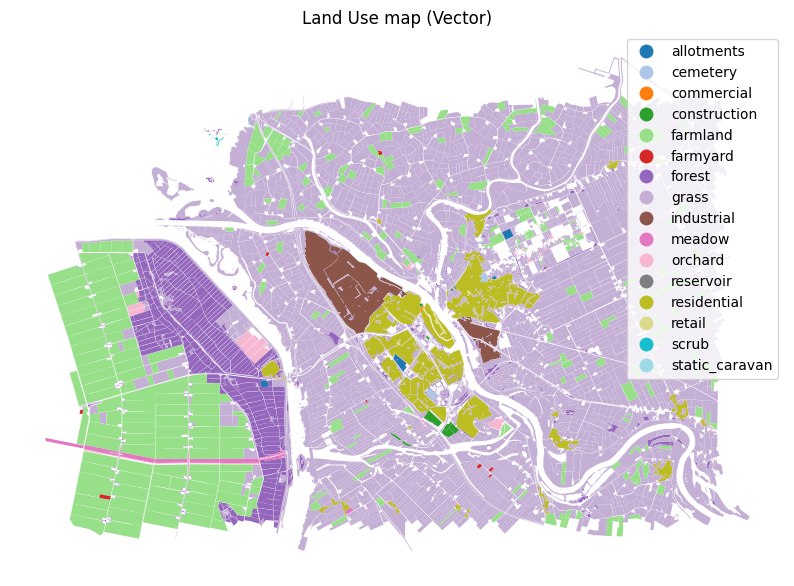

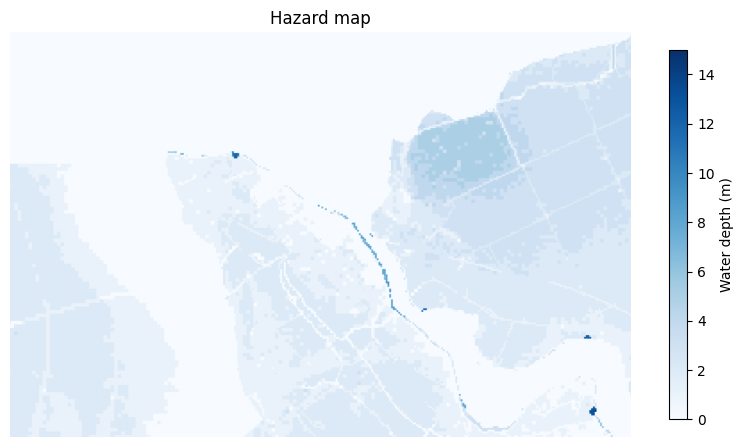

In [ ]:
curves = pd.read_csv(curve_file)
display(curves.head())

maxdam = pd.read_csv(maxdam_file)
display(maxdam.head())

landuse_data = gpd.read_file(exposure_file)
fig, ax = plt.subplots(figsize=(10, 8))
landuse_data.plot(column="landuse", ax=ax, cmap="tab20", legend=True)
plt.title("Land use map")
plt.axis("off")
plt.show()

hazard_data = rxr.open_rasterio(hazard_file).sel(band=1)
plt.figure(figsize=(10, 8))
plt.imshow(hazard_data, cmap="Blues")
plt.colorbar(label="Water depth (m)", shrink=0.6)
plt.title("Hazard map")
plt.axis("off")
plt.show()

## Run Assessment

In [ ]:
scanner = DamageScanner(hazard_file, exposure_file, curves, maxdam)
results = scanner.calculate(object_col="landuse")

print(f"Total features assessed: {len(results)}")
print(f"Total damage: €{results['damage'].sum():,.0f}")

# print 5 top-most damaged assets
results.sort_values("damage", ascending=False)[["landuse", "damage"]].head()

Calculating damage: 100%|██████████| 6615/6615 [00:01<00:00, 4932.80it/s]


Total features assessed: 6615
Total damage: €618,185,938


,landuse,damage
133,industrial,1.450076e+08
147,residential,7.766500e+07
132,industrial,3.913787e+07
158,residential,2.748671e+07
6030,industrial,2.411801e+07


## Visualize Output

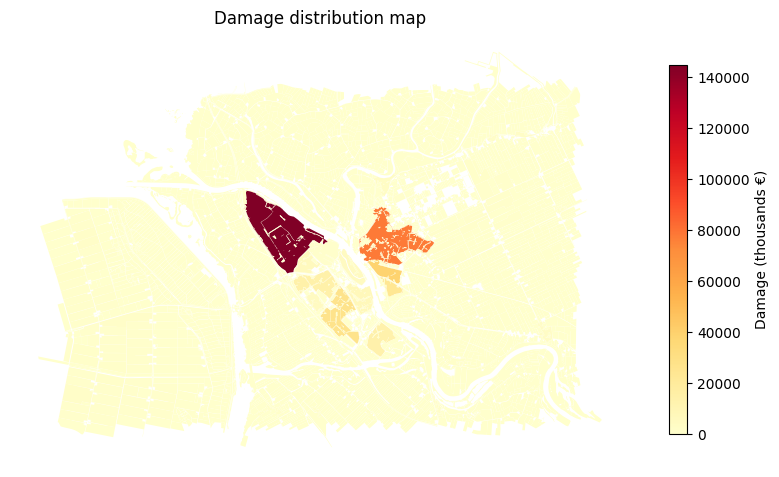

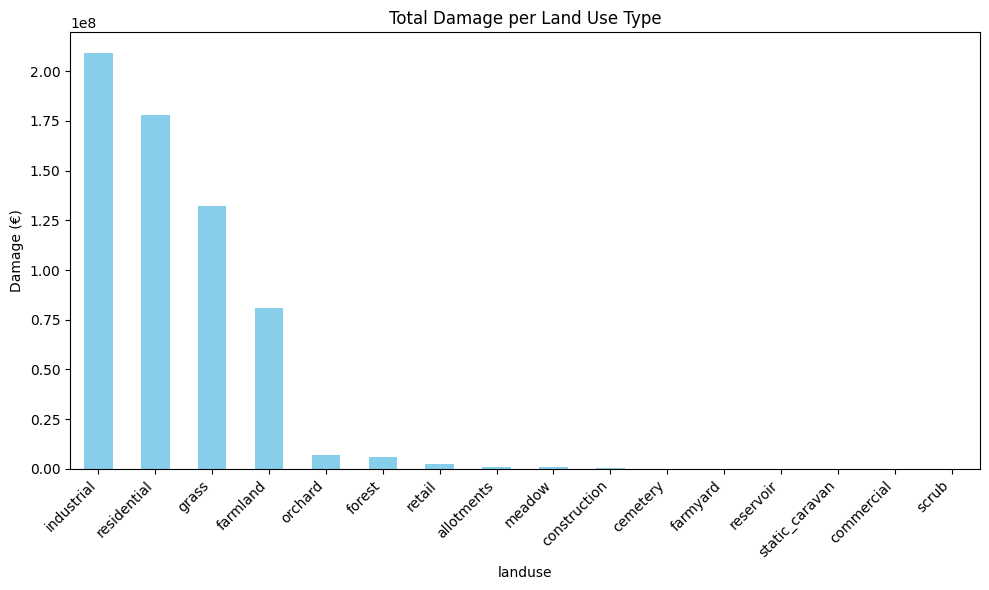

In [14]:
fig, ax = plt.subplots(figsize=(10, 8))
results["damage_thousands"] = (
    results["damage"] / 1000
)  # Convert to thousands for better visualization
results.plot(
    column="damage_thousands",
    cmap="YlOrRd",
    legend=True,
    legend_kwds={"label": "Damage (thousands €)", "shrink": 0.6},
    ax=ax,
)
plt.title("Damage distribution map")
plt.axis("off")
plt.show()

# Bar plot of damage by asset type
damage_by_type = results.groupby("landuse")["damage"].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
damage_by_type.plot(kind="bar", color="skyblue")
plt.title("Total Damage per Land Use Type")
plt.ylabel("Damage (€)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()